## Supervised Graph Learning with GNNs

In the previous chapter, we explored the foundations of unsupervised graph learning, where the main objective was to capture the structure of the graph and encode useful representations without relying on explicit labels. We introduced key concepts such as spectral and spatial graph convolution and demonstrated how Graph Convolutional Networks (GCNs) can serve as powerful encoders of node similarity and neighborhood information in an unsupervised setting.

In this section, we shift our focus to **supervised graph learning**. The primary goal here is no longer just to learn general embeddings, but rather to **optimize node or graph representations for specific predictive tasks**, such as **node classification**, **link prediction**, or **graph classification**.

While the **GNN architecture** (e.g., the convolutional layers) largely remains the same, the **learning objective** changes fundamentally. Instead of reconstructing graph structures or proximity, we now train the model to minimize a supervised loss—typically based on label prediction errors.

We will begin this chapter by reviewing shallow supervised approaches, and then delve into end-to-end **supervised Graph Neural Networks**, where the label information is directly integrated into the training process through backpropagation.



### 1.  Node Classification with Graph Convolutional Networks (GCNs)

**Objective**: Predict a label for each node using its features and the graph structure.

---

### 🧩 Inputs and Outputs

- **Input**:  
  - Node feature matrix $ \mathbf{X} \in \mathbb{R}^{N \times F} $, where:
    - $N$ = number of nodes  
    - $F$ = number of features per node  
  - Graph edge list $ \mathcal{E} $ (e.g., edge index in PyTorch Geometric)

- **Output**:  
  - Class probability matrix $ \hat{\mathbf{Y}} \in \mathbb{R}^{N \times C} $, where:
    - $C$ = number of classes

---

### ⚙️ GCN Forward Pass

Let $ f_\theta(\cdot) $ be a GCN model parameterized by $ \theta $. The forward pass computes:

$$
\hat{\mathbf{Y}} = f_\theta(\mathbf{X}, \mathcal{E})
$$

A typical GCN with two layers:

$$
\hat{\mathbf{Y}} = \text{softmax} \left( \mathbf{A}' \cdot \text{ReLU}(\mathbf{A}' \cdot \mathbf{X} \cdot \mathbf{W}^{(1)}) \cdot \mathbf{W}^{(2)} \right)
$$

Where:

- $ \mathbf{A}' = \tilde{\mathbf{D}}^{-1/2} \tilde{\mathbf{A}} \tilde{\mathbf{D}}^{-1/2} $ is the **normalized adjacency matrix with self-loops**
- $ \tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I} $
- $ \tilde{\mathbf{D}} $ is the degree matrix of $ \tilde{\mathbf{A}} $
- $ \mathbf{W}^{(1)}, \mathbf{W}^{(2)} $ are learnable weight matrices

---

### 🧮 Loss Function

The model is trained using **cross-entropy loss** on the labeled nodes:


$$
\mathcal{L} = - \frac{1}{|\mathcal{V}_L|} \sum_{i \in \mathcal{V}_L} \sum_{c=1}^C y_{ic} \log(\hat{y}_{ic})
$$
Where:

- $ \mathcal{V}_L $ is the set of labeled nodes
- $ y_i $ is the true label for node $i$
- $ \hat{y}_{i, y_i} $ is the predicted probability for the correct class

In PyTorch:

```python
import torch.nn.functional as F

loss = F.cross_entropy(pred[train_mask], labels[train_mask])
```
![GCN](../images/chap4_GCN.png)

---

🛠️ PyTorch Geometric (PyG) 

✅ **Step 1: Define the GCN Model**

```python
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv  # GCN layer from PyG

# Define a 2-layer Graph Convolutional Network (GCN)
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        # First GCN layer: transforms input features to hidden space
        self.conv1 = GCNConv(in_channels, hidden_channels)
        # Second GCN layer: transforms hidden features to output space (number of classes)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        """
        x: Node feature matrix (N x F)
        edge_index: Edge list (2 x E) in COO format
        """
        x = self.conv1(x, edge_index)  # First graph convolution
        x = F.relu(x)                  # Non-linearity
        x = self.conv2(x, edge_index)  # Second graph convolution
        return F.log_softmax(x, dim=1) # Output log-probabilities for each class
```
✅ **Step 2: Training Loop**

```python
# Instantiate the GCN model
model = GCN(
    in_channels=dataset.num_node_features,  # Number of features per node
    hidden_channels=16,                     # Size of hidden layer
    out_channels=dataset.num_classes        # Number of output classes
)

# Define the optimizer (Adam) with learning rate and L2 regularization (weight decay)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Set model to training mode (activates dropout, etc.)
model.train()

# Train for 200 epochs
for epoch in range(200):
    optimizer.zero_grad()                            # Reset gradients
    out = model(data.x, data.edge_index)             # Forward pass
    # Compute loss only on labeled training nodes
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])
    loss.backward()                                  # Backpropagation
    optimizer.step()                                 # Update weights

```
✅ **Step 3: Evaluation**

```python
# Set model to evaluation mode (disables dropout, etc.)
model.eval()

# Forward pass to get predictions
pred = model(data.x, data.edge_index).argmax(dim=1)  # Take class with highest probability

# Compare predictions with true labels on the test set
correct = pred[data.test_mask] == data.y[data.test_mask]

# Compute accuracy
acc = int(correct.sum()) / int(data.test_mask.sum())
print(f'Test Accuracy: {acc:.4f}')
```
---
### ✅ Summary

| Concept            | Explanation                                                   |
| ------------------ | ------------------------------------------------------------- |
| `GCNConv`          | Graph convolution layer from PyTorch Geometric                |
| `edge_index`       | Sparse edge list in COO format (2 × num\_edges)               |
| `data.x`           | Node feature matrix                                           |
| `data.y`           | Ground-truth labels (integers)                                |
| `data.train_mask`  | Boolean mask to specify training nodes                        |
| `F.nll_loss`       | Negative log likelihood loss (used with `log_softmax` output) |
| `argmax(dim=1)`    | Picks the class with highest predicted log-probability        |
| `optimizer.step()` | Performs one optimization (gradient descent) step             |


---

### 📚 Further Reading

- Kipf & Welling (2017): ["Semi-Supervised Classification with Graph Convolutional Networks"](https://arxiv.org/abs/1609.02907)
- [PyTorch Geometric Docs](https://pytorch-geometric.readthedocs.io)



Epoch 001, Loss: 1.9505, Train Acc: 0.9500, Val Acc: 0.7040, Test Acc: 0.7030
Epoch 020, Loss: 0.0075, Train Acc: 1.0000, Val Acc: 0.7700, Test Acc: 0.7820
Epoch 040, Loss: 0.0050, Train Acc: 1.0000, Val Acc: 0.7760, Test Acc: 0.8020
Epoch 060, Loss: 0.0125, Train Acc: 1.0000, Val Acc: 0.7840, Test Acc: 0.8160
Epoch 080, Loss: 0.0109, Train Acc: 1.0000, Val Acc: 0.7820, Test Acc: 0.8100
Epoch 100, Loss: 0.0099, Train Acc: 1.0000, Val Acc: 0.7760, Test Acc: 0.8120
Epoch 120, Loss: 0.0091, Train Acc: 1.0000, Val Acc: 0.7780, Test Acc: 0.8140
Epoch 140, Loss: 0.0084, Train Acc: 1.0000, Val Acc: 0.7800, Test Acc: 0.8100
Epoch 160, Loss: 0.0080, Train Acc: 1.0000, Val Acc: 0.7820, Test Acc: 0.8090
Epoch 180, Loss: 0.0077, Train Acc: 1.0000, Val Acc: 0.7800, Test Acc: 0.8080
Epoch 200, Loss: 0.0074, Train Acc: 1.0000, Val Acc: 0.7800, Test Acc: 0.8060

✅ Best Validation Accuracy: 0.8000
🧪 Test Accuracy at Best Validation: 0.8050


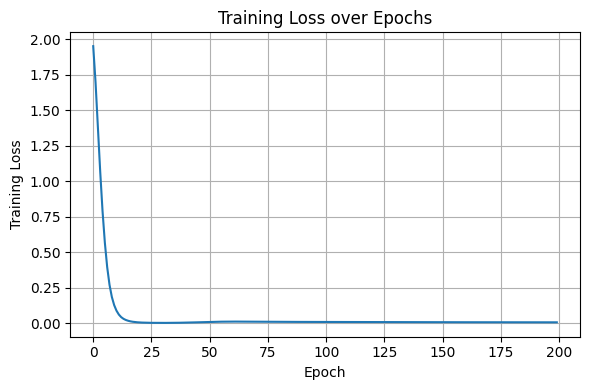

In [1]:
import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import matplotlib.pyplot as plt

# Load dataset
dataset = Planetoid(root='data/Planetoid', name='Cora')
data = dataset[0]

# Define the GCN model
class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return x

# Instantiate model, optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCN(dataset.num_node_features, 64, dataset.num_classes).to(device)
data = data.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

# Training function
def train():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

# Evaluation function
def test():
    model.eval()
    out = model(data.x, data.edge_index)
    pred = out.argmax(dim=1)

    accs = []
    for mask in [data.train_mask, data.val_mask, data.test_mask]:
        correct = pred[mask].eq(data.y[mask]).sum().item()
        acc = correct / mask.sum().item()
        accs.append(acc)
    return accs  # [train_acc, val_acc, test_acc]

# === Training Loop ===
train_losses = []
val_accuracies = []
best_val_acc = 0
best_test_acc = 0

for epoch in range(1, 201):
    loss = train()
    train_acc, val_acc, test_acc = test()
    train_losses.append(loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_test_acc = test_acc  # Save test acc at best val

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Test Acc: {test_acc:.4f}")

# Final Results
print("\n✅ Best Validation Accuracy: {:.4f}".format(best_val_acc))
print("🧪 Test Accuracy at Best Validation: {:.4f}".format(best_test_acc))

# Plot training loss
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Training Loss over Epochs')
plt.grid(True)
plt.tight_layout()
plt.show()


### 2.  Graph Classification

**Objective**: Predict a single label for an entire graph.

This task arises in many real-world domains:

- Chemistry: Predict molecule toxicity or solubility
- Bioinformatics: Predict protein functions
- NLP: Document-level classification where each document is modeled as a graph
- Social networks: Predict community type based on graph connectivity

---

####  Input and Output

- **Input**:  
  - A batch of graphs $ \{G_1, G_2, \dots, G_B\} $,  
    where each graph $ G_i$ has its own node features $ \mathbf{X}^{(i)} \in \mathbb{R}^{N_i \times F} $ and edge list $ \mathcal{E}^{(i)} $.
  - A batch vector $ \mathbf{b} \in \mathbb{R}^{\sum_i N_i}$ assigning each node to its graph ID.
    i.e. The batch vector is a 1D tensor that assigns each node in the concatenated batch to the graph it belongs to.

  
  Let’s assume we are working with a batch of $B$ graphs:

    - Graph $G_1$ has $N_1$ nodes  
    - Graph $G_2$ has $N_2$ nodes  
    - ...  
    - Graph $G_B$ has $N_B$ nodes

All node features are concatenated into a single matrix:

$$
\mathbf{X}_{\text{batch}} \in \mathbb{R}^{(N_1 + N_2 + \cdots + N_B) \times F}
$$

To tell PyTorch Geometric (PyG) which node belongs to which graph, a **batch vector** is used:

$$
\mathbf{b} = [0, 0, \ldots, 0,\, 1, 1, \ldots, 1,\, 2, \ldots, B-1]
$$

Each entry $b_j$ in the vector $\mathbf{b}$ indicates:

> Node $j$ belongs to graph $G_{b_j}$.

- **Output**:  
  - A predicted class label $ \hat{y}_i $ for each graph $ G_i $

---

###  Mathematical Formulation

1. Apply GNN layers to compute node embeddings:
$$
\mathbf{H}^{(l)} = \text{GNN}_l(\mathbf{H}^{(l-1)}, \mathcal{E})
\quad \text{with } \mathbf{H}^{(0)} = \mathbf{X}
$$

2. Aggregate (or pool) node features to a graph-level embedding:
$$
\mathbf{h}_G = \text{READOUT}(\{\mathbf{h}_v \mid v \in G\})
$$

Typical readout functions:
- Mean pooling:
  $$
  \mathbf{h}_G = \frac{1}{|G|} \sum_{v \in G} \mathbf{h}_v
  $$
- Sum pooling
- Max pooling

3. Feed the graph embedding into a classifier:
$$
\hat{y}_G = \text{softmax}(\mathbf{W} \cdot \mathbf{h}_G + \mathbf{b})
$$

![GCN_graph](../images/chap4_graphGCN.png)
---

###  Loss Function

As in node classification, we use **cross-entropy loss** over labeled graphs:

$$
\mathcal{L}_{\text{graph}} = - \frac{1}{B} \sum_{i=1}^{B} \log \hat{y}_{i, y_i}
$$

where:
- $ B $ is the number of graphs in the batch,
- $ y_i $ is the true class index of graph $ i $,
- $ \hat{y}_{i, y_i} $ is the predicted probability of the correct class.

---




Processing...
Done!


Epoch 001, Loss: 0.6730, Train Acc: 0.6533, Test Acc: 0.7105
Epoch 010, Loss: 0.5345, Train Acc: 0.7400, Test Acc: 0.6842
Epoch 020, Loss: 0.5164, Train Acc: 0.7400, Test Acc: 0.6842
Epoch 030, Loss: 0.5100, Train Acc: 0.7200, Test Acc: 0.7368
Epoch 040, Loss: 0.5065, Train Acc: 0.7533, Test Acc: 0.7632
Epoch 050, Loss: 0.5030, Train Acc: 0.7533, Test Acc: 0.7632
Epoch 060, Loss: 0.5003, Train Acc: 0.7467, Test Acc: 0.7368
Epoch 070, Loss: 0.4988, Train Acc: 0.7467, Test Acc: 0.7368
Epoch 080, Loss: 0.4975, Train Acc: 0.7467, Test Acc: 0.7368
Epoch 090, Loss: 0.4963, Train Acc: 0.7467, Test Acc: 0.7368
Epoch 100, Loss: 0.4961, Train Acc: 0.7467, Test Acc: 0.7368

✅ Best Test Accuracy: 0.7632


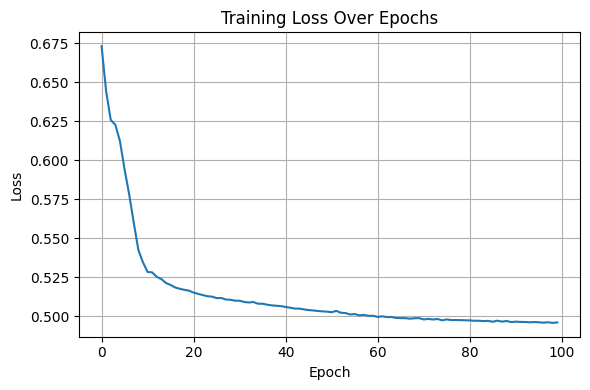

In [5]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.datasets import TUDataset
from torch_geometric.loader import DataLoader
import matplotlib.pyplot as plt

# === 1. Load Graph Classification Dataset (e.g., MUTAG or PROTEINS) ===
dataset = TUDataset(root='data/TUDataset', name='MUTAG')  # You can change to 'PROTEINS', etc.
dataset = dataset.shuffle()

# Train/test split
train_dataset = dataset[:150]
test_dataset = dataset[150:]
train_loader = DataLoader(train_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

# === 2. Define GCN for Graph Classification ===
class GCNGraphClassifier(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, hidden_channels)
        self.classifier = torch.nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)  # Aggregate node features
        return self.classifier(x)

# === 3. Setup Model, Optimizer, Loss ===
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GCNGraphClassifier(
    in_channels=dataset.num_node_features,
    hidden_channels=64,
    out_channels=dataset.num_classes
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)
criterion = torch.nn.CrossEntropyLoss()

# === 4. Training Function ===
def train():
    model.train()
    total_loss = 0
    for data in train_loader:
        data = data.to(device)
        optimizer.zero_grad()
        out = model(data.x, data.edge_index, data.batch)
        loss = criterion(out, data.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(train_dataset)

# === 5. Evaluation Function ===
def test(loader):
    model.eval()
    correct = 0
    for data in loader:
        data = data.to(device)
        out = model(data.x, data.edge_index, data.batch)
        pred = out.argmax(dim=1)
        correct += pred.eq(data.y).sum().item()
    return correct / len(loader.dataset)

# === 6. Run Training ===
train_losses = []
best_test_acc = 0

for epoch in range(1, 101):
    loss = train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)
    train_losses.append(loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d}, Loss: {loss:.4f}, "
              f"Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}")

# Final Results
print(f"\n✅ Best Test Accuracy: {best_test_acc:.4f}")

# === 7. Plot Loss Curve ===
plt.figure(figsize=(6, 4))
plt.plot(train_losses)
plt.title("Training Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.tight_layout()
plt.show()



Graph classification learns to predict labels at the graph level.

It requires aggregating (pooling) node embeddings into a single vector.

The typical pipeline includes GNN → Pooling → MLP → Softmax.

Cross-entropy loss is computed using predicted and true graph labels.



| Task                    | Description                                      | Output                  |
| ----------------------- | ------------------------------------------------ | ----------------------- |
| **Link Prediction**     | Predict whether an edge exists between two nodes | Binary classification   |
| **Edge Classification** | Predict a label for an edge                      | Multi-class (or binary) |
| **Node Regression**     | Predict a continuous value per node              | Real-valued scalar      |
| **Graph Regression**    | Predict a continuous value per graph             | Real-valued scalar      |
